## Persistence
Persistence in LangGraph refers to the ability to save and restore the state of workflow over time

In [5]:
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver
from langchain_google_genai import ChatGoogleGenerativeAI
from typing import TypedDict
import os
from dotenv import load_dotenv


In [3]:
class JokeState(TypedDict):
    topic: str
    joke: str
    explanation: str

In [6]:
load_dotenv()
api_key = os.getenv("GEMINI_API_KEY")
model = ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite", api_key=api_key)

In [11]:
def generate_joke(state: JokeState) -> JokeState:
    prompt = f"Generate a joke about {state['topic']}."
    response = model.invoke(prompt)
    return {"joke": response.content[0]["text"]}

def generate_explanation(state: JokeState) -> JokeState:
    prompt = f"Explain the joke: {state['joke']}."
    response = model.invoke(prompt)
    return {"explanation": response.content[0]["text"]}

In [13]:
graph = StateGraph(JokeState)

graph.add_node("generate_joke", generate_joke)
graph.add_node("generate_explanation", generate_explanation)

graph.add_edge(START, "generate_joke")
graph.add_edge("generate_joke", "generate_explanation")
graph.add_edge("generate_explanation", END)

checkpointer = InMemorySaver()
workflow = graph.compile(checkpointer=checkpointer)

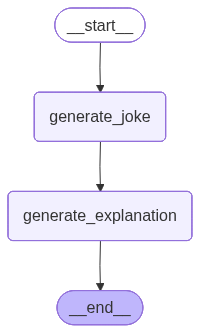

In [14]:
workflow

In [15]:
config1 = {"configurable": {"thread_id":1}}
initial_state = {"topic": "programming"}
final_state = workflow.invoke(initial_state, config=config1)

In [16]:
final_state

{'topic': 'programming',
 'joke': 'Why do programmers prefer dark mode?\n\nBecause light attracts bugs.',
 'explanation': 'The joke relies on a **pun** that connects two different worlds: the world of computer programming and the world of nature.\n\nHere is the breakdown:\n\n1.  **In the world of nature:** It is a well-known fact that light sources (like porch lights or lamps) attract insects, which are commonly referred to as **"bugs."**\n2.  **In the world of programming:** A "bug" is an error, flaw, or fault in a computer program that causes it to behave incorrectly.\n3.  **The Play on Words:** Programmers spend their days trying to fix "bugs" (coding errors). By saying "light attracts bugs," the joke playfully suggests that if a programmer uses "light mode" (a white screen background), they are literally inviting more coding errors into their work, whereas "dark mode" keeps them away. \n\nIt’s a nerdy bit of wordplay that gives human characteristics to software errors!'}

In [18]:
workflow.get_state(config1) # final state

StateSnapshot(values={'topic': 'programming', 'joke': 'Why do programmers prefer dark mode?\n\nBecause light attracts bugs.', 'explanation': 'The joke relies on a **pun** that connects two different worlds: the world of computer programming and the world of nature.\n\nHere is the breakdown:\n\n1.  **In the world of nature:** It is a well-known fact that light sources (like porch lights or lamps) attract insects, which are commonly referred to as **"bugs."**\n2.  **In the world of programming:** A "bug" is an error, flaw, or fault in a computer program that causes it to behave incorrectly.\n3.  **The Play on Words:** Programmers spend their days trying to fix "bugs" (coding errors). By saying "light attracts bugs," the joke playfully suggests that if a programmer uses "light mode" (a white screen background), they are literally inviting more coding errors into their work, whereas "dark mode" keeps them away. \n\nIt’s a nerdy bit of wordplay that gives human characteristics to software e

In [21]:
list(workflow.get_state_history(config1)) # all steps including intermediate states

[StateSnapshot(values={'topic': 'programming', 'joke': 'Why do programmers prefer dark mode?\n\nBecause light attracts bugs.', 'explanation': 'The joke relies on a **pun** that connects two different worlds: the world of computer programming and the world of nature.\n\nHere is the breakdown:\n\n1.  **In the world of nature:** It is a well-known fact that light sources (like porch lights or lamps) attract insects, which are commonly referred to as **"bugs."**\n2.  **In the world of programming:** A "bug" is an error, flaw, or fault in a computer program that causes it to behave incorrectly.\n3.  **The Play on Words:** Programmers spend their days trying to fix "bugs" (coding errors). By saying "light attracts bugs," the joke playfully suggests that if a programmer uses "light mode" (a white screen background), they are literally inviting more coding errors into their work, whereas "dark mode" keeps them away. \n\nIt’s a nerdy bit of wordplay that gives human characteristics to software 

In [22]:
config2 = {"configurable": {"thread_id":2}}
initial_state = {"topic": "artificial intelligence"}
final_state = workflow.invoke(initial_state, config=config2)

In [23]:
workflow.get_state(config2)

StateSnapshot(values={'topic': 'artificial intelligence', 'joke': 'Why did the artificial intelligence cross the road?\n\nBecause it was programmed by a chicken to optimize the pathing algorithm for maximum poultry-crossing efficiency.', 'explanation': 'The joke plays on several layers of humor, subverting the classic "Why did the chicken cross the road?" setup by shifting the perspective to the world of computer science.\n\nHere is a breakdown of why it is funny:\n\n**1. The subversion of a classic trope**\nThe original joke is a "non-sequitur"—it’s funny because it’s so simple and mundane. By asking why the *AI* crossed the road, the audience expects a technical or robotic answer. This joke provides a highly specific, overly complicated technical answer, which mocks the tendency of tech enthusiasts to over-analyze simple things.\n\n**2. Tech jargon as comedy**\nThe punchline uses terms like **"optimize," "pathing algorithm,"** and **"efficiency."** These are standard concepts in arti

In [25]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'artificial intelligence', 'joke': 'Why did the artificial intelligence cross the road?\n\nBecause it was programmed by a chicken to optimize the pathing algorithm for maximum poultry-crossing efficiency.', 'explanation': 'The joke plays on several layers of humor, subverting the classic "Why did the chicken cross the road?" setup by shifting the perspective to the world of computer science.\n\nHere is a breakdown of why it is funny:\n\n**1. The subversion of a classic trope**\nThe original joke is a "non-sequitur"—it’s funny because it’s so simple and mundane. By asking why the *AI* crossed the road, the audience expects a technical or robotic answer. This joke provides a highly specific, overly complicated technical answer, which mocks the tendency of tech enthusiasts to over-analyze simple things.\n\n**2. Tech jargon as comedy**\nThe punchline uses terms like **"optimize," "pathing algorithm,"** and **"efficiency."** These are standard concepts in art

## Benifits of persistence:
1. Short Term Memory: 
- Example: Perserving chat history of chatbot using concept of checkpointer and thread for persistence in langgraph.
2. Fault Tolerance
- Resuming the workflow from the step where it crashed.
3. Human in the Loop
- Similar to fault tolerance.
4. Time Travel
- Go back on the step to execute workflow again.
- Go back on the step and update state value and execute the workflow again from that state.

## Fault Tolerance

In [27]:
class StepState(TypedDict):
    input: str
    step1: str
    step2: str
    step3: str

In [28]:
from time import sleep

def step1(state: StepState) -> StepState:
    print("Step 1")
    return {"step1": "done"}

def step2(state: StepState) -> StepState:
    print("Step 2")
    print("Perform keyboard interrupt")
    sleep(30) # simulate a long-running step
    return {"step2": "done"}

def step3(state: StepState) -> StepState:
    print("Step 3")
    return {"step3": "done"}

In [29]:
graph = StateGraph(StepState)

graph.add_node("step1", step1)
graph.add_node("step2", step2)
graph.add_node("step3", step3)

graph.add_edge(START, "step1")
graph.add_edge("step1", "step2")
graph.add_edge("step2", "step3")   
graph.add_edge("step3", END)

checkpointer = InMemorySaver()
workflow = graph.compile(checkpointer=checkpointer)

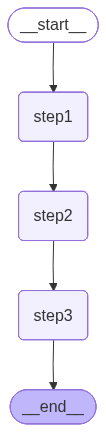

In [30]:
workflow

In [31]:
thread_id = 1
config = {"configurable": {"thread_id": thread_id}}
initial_state = {"input": "start"}
final_state = workflow.invoke(initial_state, config=config)

Step 1
Step 2
Perform keyboard interrupt


KeyboardInterrupt: 

In [33]:
workflow.get_state(config)

StateSnapshot(values={'input': 'start', 'step1': 'done'}, next=('step2',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1574e5-de76-6a48-8001-cc942d52fbc1'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-05-24T08:55:51.970874+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1574e5-de72-6030-8000-d824ea7a2b6e'}}, tasks=(PregelTask(id='1df32ae6-42df-5168-3717-856d86decdf7', name='step2', path=('__pregel_pull', 'step2'), error=None, interrupts=(), state=None, result=None),), interrupts=())

In [35]:
list(workflow.get_state_history(config))

[StateSnapshot(values={'input': 'start', 'step1': 'done'}, next=('step2',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1574e5-de76-6a48-8001-cc942d52fbc1'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-05-24T08:55:51.970874+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1574e5-de72-6030-8000-d824ea7a2b6e'}}, tasks=(PregelTask(id='1df32ae6-42df-5168-3717-856d86decdf7', name='step2', path=('__pregel_pull', 'step2'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'input': 'start'}, next=('step1',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1574e5-de72-6030-8000-d824ea7a2b6e'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-05-24T08:55:51.968977+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1574e5-de6d-657

In [36]:
# Resuming workflow from step 2 instead from start: fault tolerance demonstration
final_state =workflow.invoke(None, config=config)

Step 2
Perform keyboard interrupt
Step 3


In [37]:
workflow.get_state(config)

StateSnapshot(values={'input': 'start', 'step1': 'done', 'step2': 'done', 'step3': 'done'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1574f2-ae1c-68a9-8003-04a1a1aa4055'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2026-05-24T09:01:35.866896+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1574f2-ae0b-6bdd-8002-92028d534a2c'}}, tasks=(), interrupts=())

In [38]:
list(workflow.get_state_history(config))

[StateSnapshot(values={'input': 'start', 'step1': 'done', 'step2': 'done', 'step3': 'done'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1574f2-ae1c-68a9-8003-04a1a1aa4055'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2026-05-24T09:01:35.866896+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1574f2-ae0b-6bdd-8002-92028d534a2c'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'input': 'start', 'step1': 'done', 'step2': 'done'}, next=('step3',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1574f2-ae0b-6bdd-8002-92028d534a2c'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-05-24T09:01:35.860015+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1574e5-de76-6a48-8001-cc942d52fbc1'}}, tasks=(PregelTask(id='1e554702-97d8-650c-9f2b-ebb821213eda', name='st

## Time Travel